# Japan — Full Piotroski F-Score Study

The proposal's complete loop on **real data**: point-in-time universe →
high-B/M value subset → 9-signal F-Score → fixed-basket selection (F-Score vs
value / market-cap / liquidity-matched / random Monte-Carlo) → EW / GMV /
sector-capped GMV on RMT-cleaned covariances, plus a dollar-neutral
long-short book (long top-k scores, short bottom-k) where shorting is
available → annual-rebalance backtest →
placement in the random distribution → investable benchmarks → Fama-French
three-factor regression.

**Data & scope.** Bloomberg statements from `data/processed/Japan/`, which carry fiscal years back to 2000 and so lift Japan onto the **same July 2012 – July 2024 window as the US** — thirteen chained holding years, replacing the two formations the old Yahoo cache allowed. Book equity comes from `Common_Shareholders_Equity`; the vendor's own `Book_Value`, `Historical_Market_Cap` and `Proceeds_Issuance_Common_Stock` columns are **empty in every sheet**, so market cap is rebuilt as raw close × shares outstanding and EQ_OFFER falls back to the share count — the generous measure (see `results/eq_offer_sensitivity.csv`). The universe is the **TPX100** constituent list as of each formation date, so index-inclusion look-ahead is removed — but it is only ~100 names, and the high-B/M subset is correspondingly small: a 30-name basket is 83–91% of it, which leaves the random-basket comparison little room to separate anything. The grid's **k = 20** cell is the interpretable one for Japan; k = 30 is kept here for continuity with the US. Report dates are fiscal period ends; the reporting lag is 3 months — the statutory deadline for the securities report (yukashoken hokokusho), so a March fiscal year is public by end-June, just before formation. **Prices are not from this vendor tree**: its price workbook is empty in both markets (its own `price_coverage.xlsx` records `Has_Any_Adjusted_Price = False` for every name), so prices come from the Yahoo cache. That covers 97–100% of each formation's constituents; the names it cannot serve — Toshiba, Bank of Yokohama, NTT Docomo — are delisted or merged, which is the residual survivorship bias stated plainly.

Run `python scripts/build_japan_bbg.py`
once before this notebook (builds the git-ignored cache under `data/`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.plotting import setup_plots, save_fig
from fscore.data.yahoo import load_cached
from fscore.pipeline import run_study
from fscore.evaluation import (metrics, benchmark_returns, fetch_ff_factors,
                               factor_regression, to_usd)

setup_plots()      # study-wide figure defaults; every saved chart is 300 dpi
RESULTS_FIG = ROOT / "results" / "figures"
MARKET = "japan"
YEARS = list(range(2012, 2025))
LAG_MONTHS = 3  # report_date = fiscal period end; the lag is applied on top
END_CAP = None   # every holding year is complete; nothing is truncated
from fscore.data.bbg_processed import constituents
fund = pd.read_csv(ROOT / "data" / "japan_bbg_fundamentals.csv",
                   parse_dates=["report_date"])
prices = pd.read_csv(ROOT / "data" / "japan_prices.csv.gz", parse_dates=["date"])
sectors = pd.read_csv(ROOT / "data" / "japan_sectors.csv").set_index("ticker")["sector"]
bench = pd.read_csv(ROOT / "data" / "japan_benchmarks.csv.gz", parse_dates=["date"])
membership = constituents(MARKET, ROOT / "data", YEARS)
print(f"fundamentals: {fund.ticker.nunique()} tickers, "
      f"FY{fund.fiscal_year.min()}–FY{fund.fiscal_year.max()}")
print(f"prices: {prices.ticker.nunique()} tickers, "
      f"{prices.date.min():%Y-%m-%d} → {prices.date.max():%Y-%m-%d}")
fund.groupby("fiscal_year").size().rename("statements")

fundamentals: 139 tickers, FY2009–FY2024
prices: 237 tickers, 2002-01-01 → 2026-08-27


fiscal_year
2009    100
2010    110
2011    111
2012    103
2013    105
2014    104
2015    103
2016    104
2017    107
2018    109
2019    108
2020    105
2021    105
2022    106
2023    102
2024    100
Name: statements, dtype: int64

### 1. Run the multi-year study

Per formation year: universe = top-150 names by median dollar volume with
continuous listing and complete, published statements; value subset = top 40%
by B/M (~60 names); baskets of 30; 1,000 random baskets under EW (300 pushed
through the GMV / sector-GMV pipeline).

**Data discarded before any test.** A firm-year is scored
only when all nine signals are computable from the fiscal T-1 and T-2
statements; partial scores are dropped rather than summed over whatever is
available (an incomplete score is not a low score). The per-formation count
is `dropped_incomplete_signals` in the diagnostics below.

In [2]:
study = run_study(MARKET, fund, prices, sectors, YEARS,
                  n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                  membership=membership, end_cap=END_CAP, seed=42,
                  detone=False)   # RMT denoise only — detoning is
                                  # out of scope for this study
diag = pd.DataFrame([{"year": yr.year, **yr.diagnostics} for yr in study.yearly])
diag.set_index("year")

,universe,value_set,scored,dropped_incomplete_signals,tie_break_slots,cov_est_days,delisted_in_holding_year,k,fscore_mean,fscore_basket_min
year,,,,,,,,,,
2012,82,33,32,19,8,733,0,30,7.218750,6
2013,82,33,33,16,1,734,0,30,5.454545,3
2014,82,33,33,16,3,736,0,30,6.121212,4
2015,82,33,33,16,4,735,0,30,6.333333,5
2016,82,33,33,17,5,734,0,30,6.484848,5
2017,84,34,34,16,4,735,0,30,5.941176,4
2018,85,34,34,15,4,750,0,30,6.352941,5
2019,84,34,34,15,12,753,0,30,6.588235,6
2020,84,34,34,16,2,751,0,30,5.764706,4


### 2. F-Score distribution within the value universe, per formation

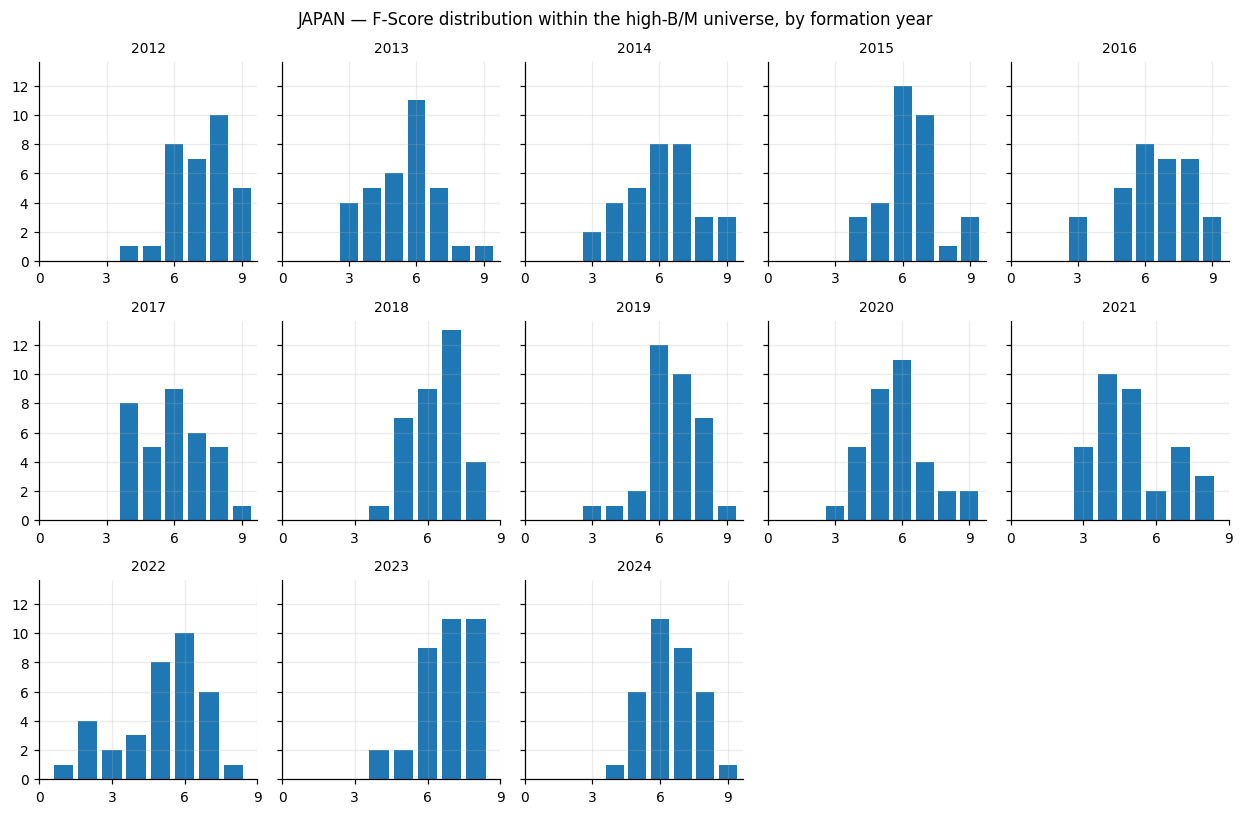

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,32.00,33.00,33.00,33.00,33.00,34.00,34.00,34.00,34.00,34.00,35.00,35.00,34.00
mean,7.22,5.45,6.12,6.33,6.48,5.94,6.35,6.59,5.76,5.03,5.06,6.77,6.47
std,1.26,1.48,1.63,1.29,1.64,1.48,1.04,1.23,1.42,1.55,1.76,1.14,1.16
min,4.00,3.00,3.00,4.00,3.00,4.00,4.00,3.00,3.00,3.00,1.00,4.00,4.00
25%,6.00,4.00,5.00,6.00,6.00,5.00,6.00,6.00,5.00,4.00,4.00,6.00,6.00
50%,7.00,6.00,6.00,6.00,7.00,6.00,6.50,7.00,6.00,5.00,5.00,7.00,6.00
75%,8.00,6.00,7.00,7.00,8.00,7.00,7.00,7.00,6.00,6.00,6.00,8.00,7.00
max,9.00,9.00,9.00,9.00,9.00,9.00,8.00,9.00,9.00,8.00,8.00,8.00,9.00


In [3]:
ncol = min(5, len(YEARS))
nrow = -(-len(YEARS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 2.5 * nrow),
                         sharey=True, squeeze=False)
for ax, yr in zip(axes.flat, study.yearly):
    counts = yr.scored.fscore.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{yr.year}", fontsize=9); ax.set_xticks(range(0, 10, 3))
for ax in axes.flat[len(study.yearly):]:
    ax.axis("off")
fig.suptitle(f"{MARKET.upper()} — F-Score distribution within the high-B/M universe, by formation year")
plt.tight_layout(); save_fig(f"{MARKET}_fscore_distribution", directory=RESULTS_FIG); plt.show()

pd.DataFrame({yr.year: yr.scored.fscore.describe() for yr in study.yearly}).round(2)

### 3. Chained track record vs investable benchmarks

1306.T is JPY like the portfolios; EWJV is USD, so its row mixes in currency effects and is indicative only.

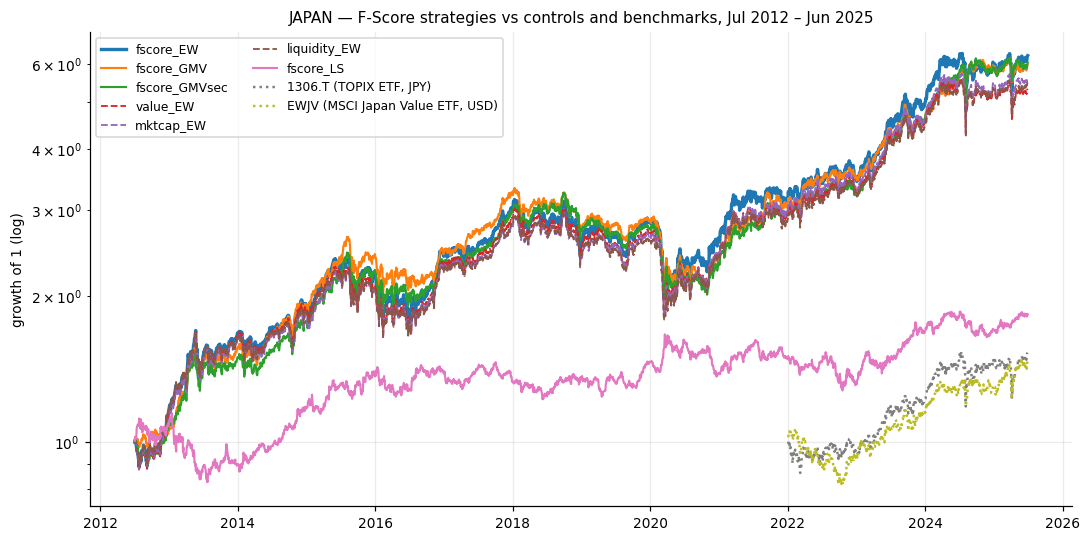

In [4]:
BENCH = {"1306.T (TOPIX ETF, JPY)": "1306.T",
         "EWJV (MSCI Japan Value ETF, USD)": "EWJV"}
start, end = study.daily.index.min(), study.daily.index.max()
bench_rets = {name: benchmark_returns(bench, tk, start, end)
              for name, tk in BENCH.items()}

nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
# solid for the F-Score variants, dashed for the controls; a strategy not
# named here still plots, so adding one never breaks the figure
styles = {"fscore_EW": ("-", 2.2), "fscore_GMV": ("-", 1.4), "fscore_GMVsec": ("-", 1.4),
          "fscore_LS": ("-", 1.4),
          "value_EW": ("--", 1.2), "mktcap_EW": ("--", 1.2), "liquidity_EW": ("--", 1.2)}
for s in study.daily.columns:
    ls, lw = styles.get(s, ("-" if s.startswith("fscore") else "-.", 1.2))
    ax.plot(nav.index, nav[s], ls, lw=lw, label=s)
for name, r in bench_rets.items():
    ax.plot((1 + r).cumprod(), ":", lw=1.6, label=name)
ax.set_ylabel("growth of 1 (log)"); ax.set_yscale("log")
ax.set_title(f"{MARKET.upper()} — F-Score strategies vs controls and benchmarks, "
             f"{start:%b %Y} – {end:%b %Y}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
save_fig(f"{MARKET}_nav_vs_benchmarks", directory=RESULTS_FIG); plt.show()

In [5]:
tbl = study.summary()      # gross first; costs follow separately
for name, r in bench_rets.items():
    tbl.loc[name] = metrics(r)   # benchmarks are buy-and-hold: no turnover
tbl[["ann_return", "ann_vol", "sharpe", "max_drawdown",
     "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.156,0.205,0.758,-0.374,30.0,30.000
fscore_GMV,0.152,0.178,0.851,-0.378,30.0,4.995
fscore_GMVsec,0.152,0.181,0.845,-0.387,30.0,7.077
value_EW,0.141,0.205,0.688,-0.392,30.0,30.000
mktcap_EW,0.146,0.205,0.714,-0.381,30.0,30.000
liquidity_EW,0.144,0.204,0.705,-0.398,30.0,30.000
fscore_LS,0.049,0.140,0.348,-0.278,32.0,13.087
"1306.T (TOPIX ETF, JPY)",0.133,0.195,0.682,-0.228,NaN,NaN
"EWJV (MSCI Japan Value ETF, USD)",0.114,0.181,0.629,-0.233,NaN,NaN


`nominal_k` is the basket size, `effective_n` is 1/Σw² —
an optimised or sector-capped book concentrates, so the two are not the same
number of holdings. Turnover and the net-of-cost sensitivity follow below.

In [6]:
tbl[["turnover", "cost_drag",
     "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.3134,0.0013,0.1543,0.7524
fscore_GMV,0.4483,0.0018,0.1500,0.8413
fscore_GMVsec,0.4637,0.0019,0.1506,0.8344
value_EW,0.2377,0.0010,0.1404,0.6839
mktcap_EW,0.2602,0.0010,0.1451,0.7085
liquidity_EW,0.3178,0.0013,0.1427,0.6991
fscore_LS,1.2773,0.0151,0.0337,0.2402
"1306.T (TOPIX ETF, JPY)",NaN,NaN,NaN,NaN
"EWJV (MSCI Japan Value ETF, USD)",NaN,NaN,NaN,NaN


### 4. Statistical control — placement in the Monte-Carlo random distribution

Same universe, same basket size, same construction pipeline; the only
difference is *which* 30 names. Percentile = share of random baskets the
F-Score portfolio beats; the p-value is one-sided and judged at the study's
single significance level, **5%** (`significant` column). No 1% or 10% tier
is used, so p = 0.06 counts as not significant.

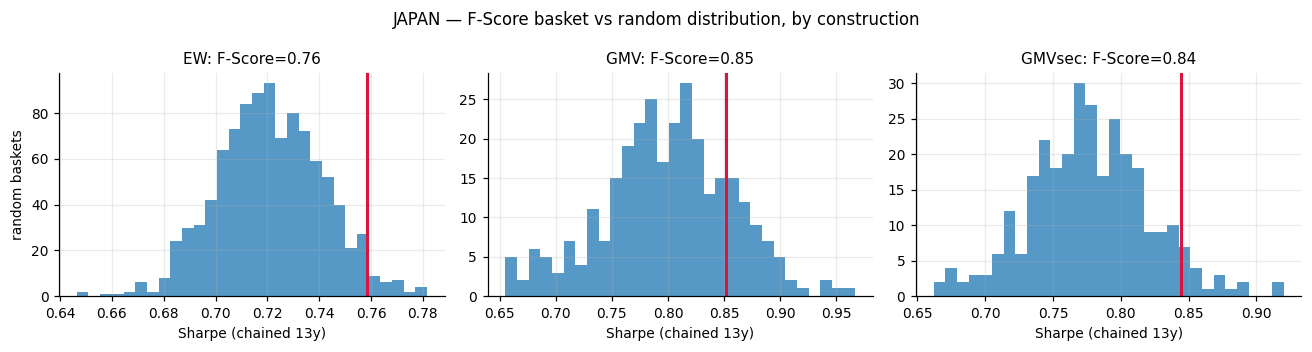

fscore random_mean random_std percentile  \
fscore_EW     ann_return    0.155557    0.147582   0.004141      0.975   
              sharpe        0.758466    0.721117   0.020389      0.968   
              max_drawdown -0.373973    -0.38706   0.011436      0.878   
fscore_GMV    ann_return    0.151782    0.143312   0.009907   0.793333   
              sharpe        0.851353    0.799178    0.05777       0.81   
              max_drawdown -0.377652   -0.384552   0.029571   0.576667   
fscore_GMVsec ann_return    0.152464    0.140372   0.007789   0.933333   
              sharpe        0.844634    0.777085   0.043968       0.94   
              max_drawdown -0.387021   -0.400636   0.023285   0.736667   

                             p_value significant n_draws  
fscore_EW     ann_return       0.025        True    1000  
              sharpe           0.032        True    1000  
              max_drawdown     0.122       False    1000  
fscore_GMV    ann_return    0.206667       False     300  
              sharpe            0.19       False     300  
              max_drawdown  0.423333       False     300  
fscore_GMVsec ann_return    0.066667       False     300  
              sharpe            0.06       False     300  
              max_drawdown  0.263333       False     300

In [7]:
pairs = [("EW", "fscore_EW"), ("GMV", "fscore_GMV"), ("GMVsec", "fscore_GMVsec")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, (how, strat) in zip(axes, pairs):
    sharpes = study.mc_summary(how)["sharpe"].dropna()
    fs = metrics(study.daily[strat].dropna())["sharpe"]
    ax.hist(sharpes, bins=30, alpha=0.75)
    ax.axvline(fs, color="crimson", lw=2)
    ax.set_title(f"{how}: F-Score={fs:.2f}", fontsize=10)
    ax.set_xlabel(f"Sharpe (chained {len(YEARS)}y)")
axes[0].set_ylabel("random baskets")
fig.suptitle(f"{MARKET.upper()} — F-Score basket vs random distribution, by construction")
plt.tight_layout(); save_fig(f"{MARKET}_mc_placement", directory=RESULTS_FIG); plt.show()

placements = pd.concat({strat: study.placement(strat, how) for how, strat in pairs})
placements.round(3)

### 5. Turnover and implied trading cost

One-way turnover per rebalance, computed on each strategy's actual weights
(so GMV pays for weight drift, not just for name changes); cost drag =
2 x turnover x 20 bp per side, already applied in the `net_*` columns above.
For reference, the random control is redrawn every year and turns over
roughly `1 - k/|universe|`, i.e. in the same range as the F-Score basket.

In [8]:
to = study.turnover_table()
to.loc["mean"] = to.mean()
cost = (2 * to.loc["mean"] * 0.0020).rename("annual cost drag")
pd.concat([to.round(3).T, cost.round(4)], axis=1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,mean,annual cost drag
fscore_EW,0.373,0.332,0.248,0.372,0.294,0.270,0.301,0.287,0.385,0.333,0.275,0.289,0.313,0.0013
fscore_GMV,0.344,0.419,0.250,0.726,0.487,0.337,0.393,0.482,0.464,0.751,0.302,0.424,0.448,0.0018
fscore_GMVsec,0.380,0.315,0.244,0.706,0.478,0.483,0.467,0.499,0.505,0.551,0.396,0.541,0.464,0.0019
fscore_LS,1.373,1.332,1.248,1.372,1.294,1.020,1.301,1.287,1.385,1.333,1.091,1.289,1.277,0.0051
value_EW,0.309,0.236,0.192,0.244,0.162,0.162,0.201,0.265,0.227,0.258,0.360,0.237,0.238,0.0010
mktcap_EW,0.307,0.236,0.218,0.334,0.264,0.247,0.299,0.274,0.263,0.244,0.259,0.177,0.260,0.0010
liquidity_EW,0.342,0.279,0.218,0.361,0.300,0.316,0.361,0.304,0.349,0.279,0.395,0.309,0.318,0.0013


### 6. Does alpha survive the factor exposures?

Daily excess returns regressed on the Fama-French three factors (market,
size, value) with Newey-West standard errors. The `alpha_significant` column
is the verdict at the study's single level, 5%. Japan portfolio returns are converted to USD to match the USD-denominated Japan factor set.

In [9]:
ff = fetch_ff_factors("japan")
# Ken French Japan factors are USD-denominated -> convert JPY returns to USD
fx = bench[bench.ticker == "JPY=X"].set_index("date")["adj_close"]
series = {s: to_usd(study.daily[s].dropna(), fx)
          for s in ["fscore_EW", "fscore_GMV", "value_EW"]}
reg = pd.DataFrame({s: factor_regression(r, ff) for s, r in series.items()}).T
reg.round(4)

,alpha_daily,alpha_annual,alpha_tstat,alpha_pvalue,alpha_significant,alpha,beta_mkt,beta_smb,beta_hml,r2,n_obs
fscore_EW,0.00032,0.080686,1.521528,0.128127,False,0.05,0.634291,-0.193543,0.006439,0.491918,851
fscore_GMV,0.000374,0.094321,1.566829,0.117155,False,0.05,0.417344,-0.071964,-0.071986,0.300888,851
value_EW,0.000215,0.054173,1.046364,0.295393,False,0.05,0.617251,-0.161712,0.027823,0.480512,851


In [10]:
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
tbl.to_csv(RESULTS / f"{MARKET}_summary.csv")
placements.to_csv(RESULTS / f"{MARKET}_mc_placement.csv")
to.to_csv(RESULTS / f"{MARKET}_turnover.csv")
reg.to_csv(RESULTS / f"{MARKET}_factor_regression.csv")
diag.to_csv(RESULTS / f"{MARKET}_diagnostics.csv", index=False)
print("saved to", RESULTS)

saved to C:\Users\miked\OneDrive\Desktop\Career\WQU\Cap Project\fscore_capstone\results


### 7. Reading the results

*(filled in after execution)*